In [1]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    precision_recall_curve
)

In [2]:
file_path = "Churn_Modelling.csv"
df = pd.read_csv(file_path)

print(tabulate(df.head(), tablefmt='psql', headers='keys'))

+----+-------------+--------------+-----------+---------------+-------------+----------+-------+----------+-----------+-----------------+-------------+------------------+-------------------+----------+
|    |   RowNumber |   CustomerId | Surname   |   CreditScore | Geography   | Gender   |   Age |   Tenure |   Balance |   NumOfProducts |   HasCrCard |   IsActiveMember |   EstimatedSalary |   Exited |
|----+-------------+--------------+-----------+---------------+-------------+----------+-------+----------+-----------+-----------------+-------------+------------------+-------------------+----------|
|  0 |           1 |     15634602 | Hargrave  |           619 | France      | Female   |    42 |        2 |       0   |               1 |           1 |                1 |          101349   |        1 |
|  1 |           2 |     15647311 | Hill      |           608 | Spain       | Female   |    41 |        1 |   83807.9 |               1 |           0 |                1 |          112543   |  

In [3]:
# --- Numeric Correlation vs Exited ---
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

correlations = df[numeric_cols].corrwith(df['Exited']).sort_values(key=abs, ascending=False)
print(correlations.to_string())

# --- Chi-Squared for Categorical/Binary columns vs Exited ---
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Exited'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.4f} -> {'Significant' if p < 0.05 else 'Not significant'}")

Age                0.285323
Balance            0.118533
NumOfProducts     -0.047820
CreditScore       -0.027094
Tenure            -0.014001
EstimatedSalary    0.012097
Geography: chi2=301.26, p-value=0.0000 -> Significant
Gender: chi2=112.92, p-value=0.0000 -> Significant
HasCrCard: chi2=0.47, p-value=0.4924 -> Not significant
IsActiveMember: chi2=242.99, p-value=0.0000 -> Significant


## Feature Engineering (Full Dataset)
BQ: "Which customers are at risk of churning, and what distinguishes them from those who stay?"

In [4]:
# --- Feature Engineering on full dataset ---
fe_df = df.copy()

# Gender: Female=1, Male=0
fe_df['Gender_Female'] = (fe_df['Gender'] == 'Female').astype(int)

# Geography: one dummy per country (keep all 3 for tree-based models)
fe_df['Geo_France']  = (fe_df['Geography'] == 'France').astype(int)
fe_df['Geo_Germany'] = (fe_df['Geography'] == 'Germany').astype(int)
fe_df['Geo_Spain']   = (fe_df['Geography'] == 'Spain').astype(int)

# NumOfProducts: dummy per tier
fe_df['Products_1']    = (fe_df['NumOfProducts'] == 1).astype(int)
fe_df['Products_2']    = (fe_df['NumOfProducts'] == 2).astype(int)
fe_df['Products_3plus'] = (fe_df['NumOfProducts'] >= 3).astype(int)

# HasCrCard excluded — chi-squared shows no significant association with churn (p=0.49)
# EstimatedSalary excluded — near-zero correlation with churn (r=0.012)
feature_cols = [
    'Gender_Female', 'Age', 'CreditScore', 'Tenure',
    'Geo_France', 'Geo_Germany', 'Geo_Spain',
    'Balance',
    'Products_1', 'Products_2', 'Products_3plus',
    'IsActiveMember'
]

X = fe_df[feature_cols]
y = fe_df['Exited']

print('Class distribution (Exited):')
print(y.value_counts())
print(f"\nOverall churn rate: {y.mean()*100:.1f}%")

Class distribution (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Overall churn rate: 20.4%


## EDA  Deeper Look (Full Dataset)

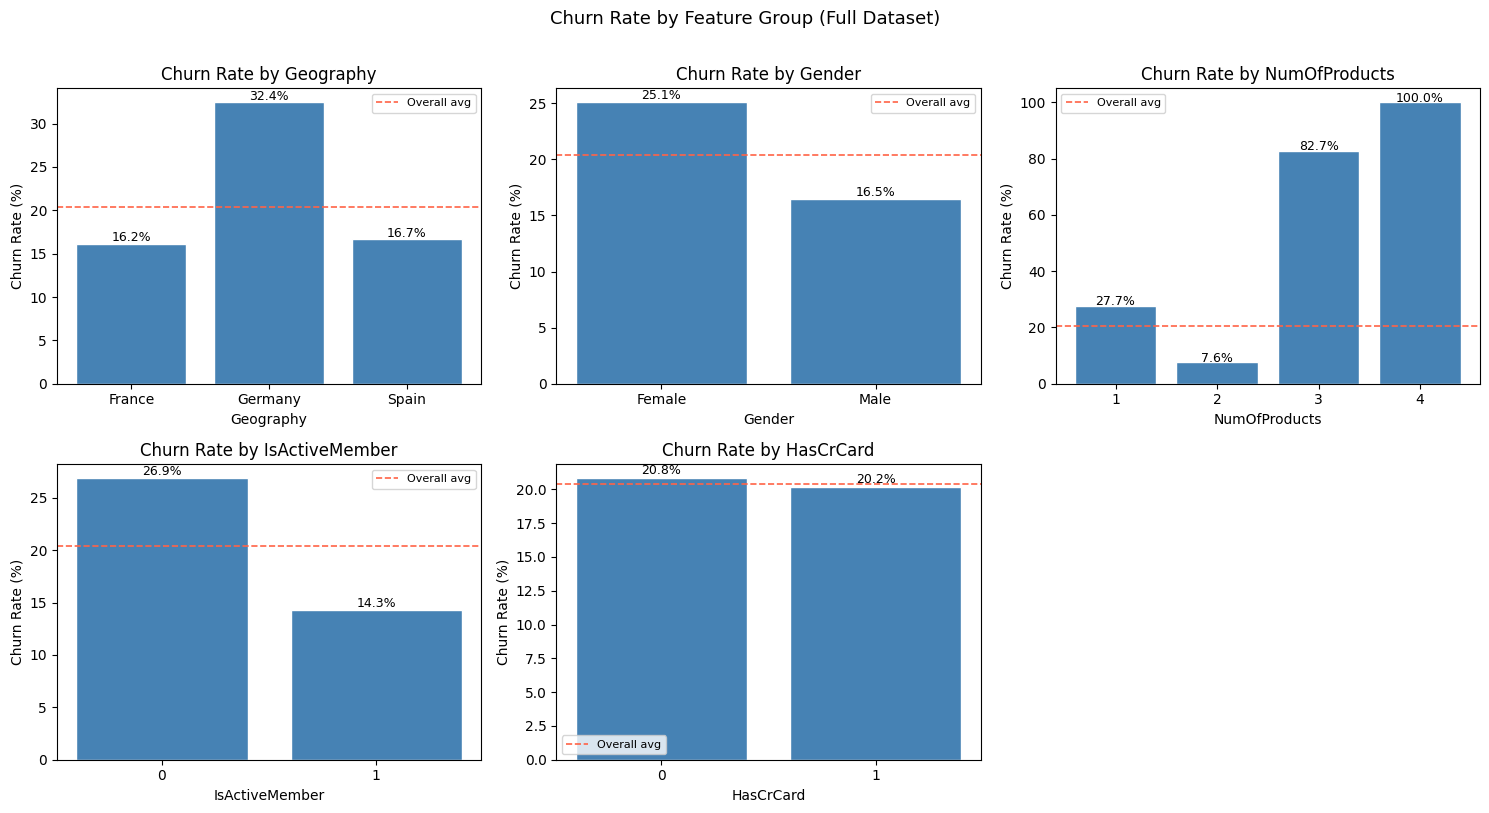

In [5]:
# --- Churn rate by categorical/binary features ---
cat_features = {
    'Geography': df['Geography'],
    'Gender': df['Gender'],
    'NumOfProducts': df['NumOfProducts'],
    'IsActiveMember': df['IsActiveMember'],
    'HasCrCard': df['HasCrCard']
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (name, series) in zip(axes, cat_features.items()):
    churn_rate = df.groupby(series)['Exited'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values, color='steelblue', edgecolor='white')
    ax.axhline(y=df['Exited'].mean() * 100, color='tomato', linestyle='--', linewidth=1.2, label='Overall avg')
    ax.set_title(f'Churn Rate by {name}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(name)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Churn Rate by Feature Group (Full Dataset)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

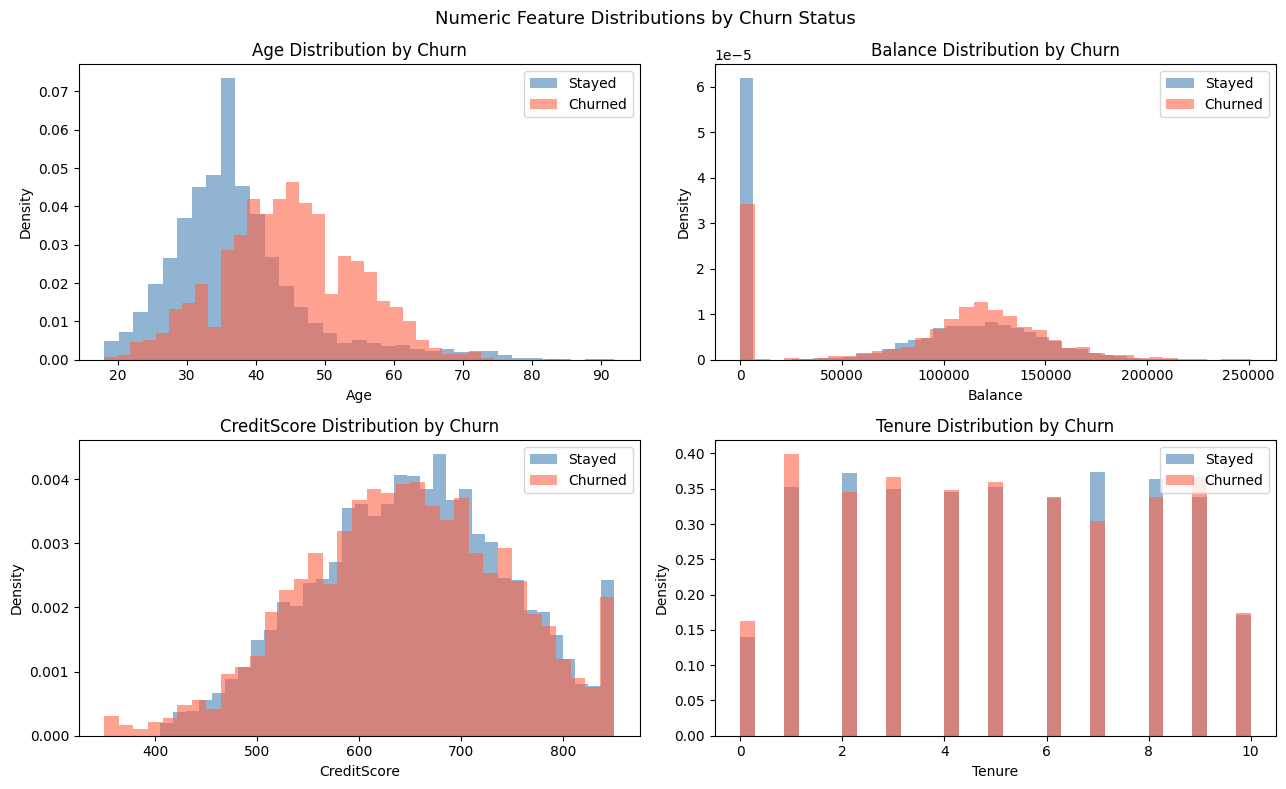

In [6]:
# --- Numeric distributions by churn status ---
numeric_features = ['Age', 'Balance', 'CreditScore', 'Tenure']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    for exited_val, label, color in [(0, 'Stayed', 'steelblue'), (1, 'Churned', 'tomato')]:
        subset = df[df['Exited'] == exited_val][col]
        ax.hist(subset, bins=35, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'{col} Distribution by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=13)
plt.tight_layout()
plt.show()

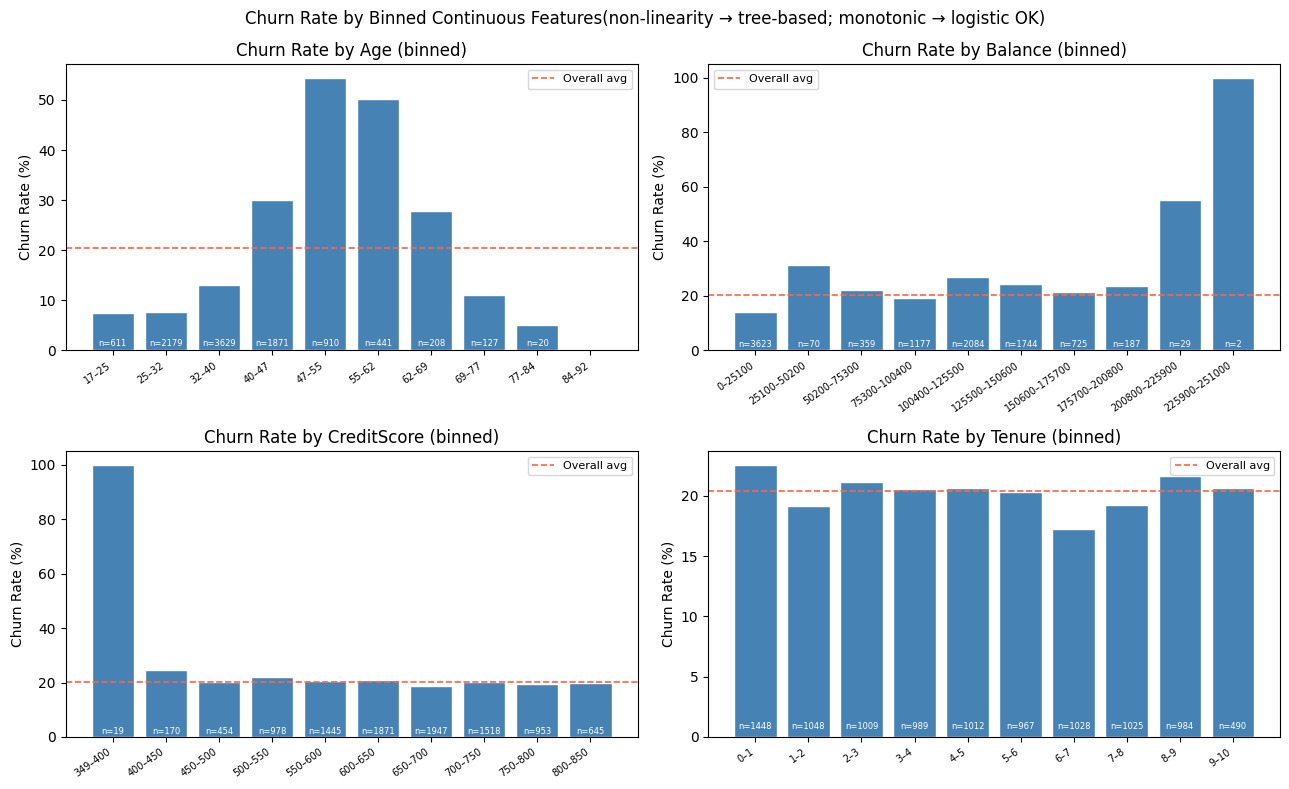

In [7]:
# --- Churn rate by binned continuous features ---
# This reveals the shape of the relationship (linear vs non-linear) between each feature and churn

bin_configs = {
    'Age':         {'bins': 10, 'range': (18, 92)},
    'Balance':     {'bins': 10, 'range': (0, 251000)},
    'CreditScore': {'bins': 10, 'range': (350, 850)},
    'Tenure':      {'bins': 10, 'range': (0, 10)},
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (col, cfg) in zip(axes, bin_configs.items()):
    edges = np.linspace(cfg["range"][0], cfg["range"][1], cfg["bins"] + 1).astype(int)
    temp = df[[col, "Exited"]].copy()
    temp["bin"] = pd.cut(temp[col], bins=edges, include_lowest=True)
    binned = temp.groupby("bin", observed=True)["Exited"].agg(["mean", "count"]).reset_index()
    binned["mean"] *= 100
    bin_labels = [f"{int(b.left)}–{int(b.right)}" for b in binned["bin"]]

    bars = ax.bar(range(len(binned)), binned["mean"], color="steelblue", edgecolor="white")
    ax.axhline(y=df["Exited"].mean() * 100, color="tomato", linestyle="--", linewidth=1.2, label="Overall avg")
    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels(bin_labels, rotation=35, ha="right", fontsize=7)
    ax.set_title(f"Churn Rate by {col} (binned)")
    ax.set_ylabel("Churn Rate (%)")
    ax.legend(fontsize=8)

    # annotate count per bin
    for bar, cnt in zip(bars, binned["count"]):
        ax.text(bar.get_x() + bar.get_width()/2, 0.5, f"n={cnt}", ha="center", va="bottom", fontsize=6, color="white")

plt.suptitle("Churn Rate by Binned Continuous Features(non-linearity → tree-based; monotonic → logistic OK)", fontsize=12)
plt.tight_layout()
plt.show()

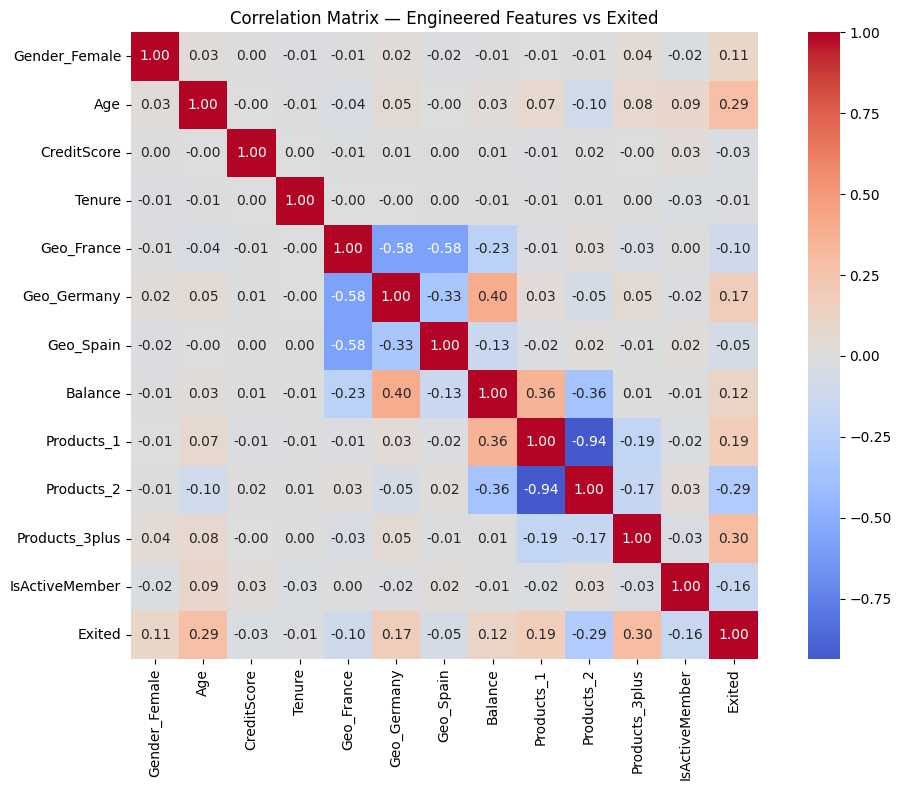

In [8]:
# --- Correlation of all engineered features vs Exited ---
corr_cols = feature_cols + ['Exited']
corr_matrix = fe_df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Engineered Features vs Exited')
plt.tight_layout()
plt.show()

## Modeling

In [9]:
# --- Train / Test Split ---
# Stratify to preserve class balance across both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Train size: 7000 | Test size: 3000
Train churn rate: 20.4%
Test churn rate:  20.4%


In [10]:
# --- GridSearchCV: Decision Tree ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print(f"Best CV AUC:  {dt_grid.best_score_:.4f}")

Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV AUC:  0.8271


In [11]:
# --- GridSearchCV: Random Forest ---
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print(f"Best CV AUC:  {rf_grid.best_score_:.4f}")

Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV AUC:  0.8551


In [12]:
# --- GridSearchCV: XGBoost ---
# scale_pos_weight handles class imbalance: ratio of negatives to positives
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [neg / pos]   # handles class imbalance
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', verbosity=0),
    xgb_params, cv=cv, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print(f"Best CV AUC:  {xgb_grid.best_score_:.4f}")

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': np.float64(3.908835904628331)}
Best CV AUC:  0.8601


## Model Evaluation

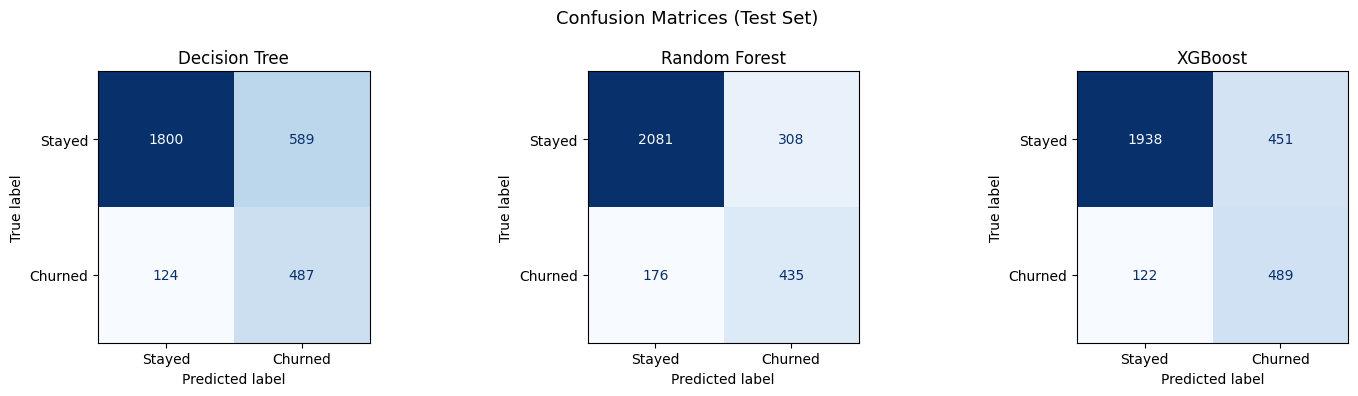

In [13]:
# --- Confusion Matrices ---
models = {
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost':       xgb_grid.best_estimator_
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# --- Precision, Recall, F1, AUC Summary ---
cv_scores = {
    'Decision Tree': dt_grid.best_score_,
    'Random Forest': rf_grid.best_score_,
    'XGBoost':       xgb_grid.best_score_
}

results = []
for name, model in models.items():
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_pred       = model.predict(X_test)
    y_prob_test  = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model':        name,
        'Train AUC':    roc_auc_score(y_train, y_prob_train),
        'CV AUC':       cv_scores[name],
        'Test AUC':     roc_auc_score(y_test, y_prob_test),
        'Precision':    precision_score(y_test, y_pred),
        'Recall':       recall_score(y_test, y_pred),
        'F1':           f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4).to_string())

               Train AUC  CV AUC  Test AUC  Precision  Recall      F1
Model                                                                
Decision Tree     0.8504  0.8271    0.8479     0.4526  0.7971  0.5774
Random Forest     0.9403  0.8551    0.8743     0.5855  0.7119  0.6425
XGBoost           0.8928  0.8601    0.8841     0.5202  0.8003  0.6306


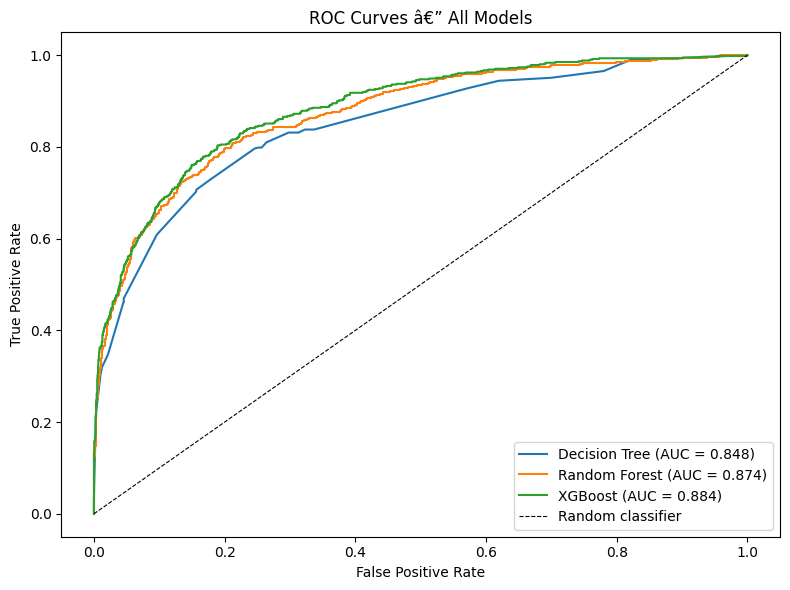

In [15]:
# --- ROC Curves (all three models on one plot) ---
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves â€” All Models')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

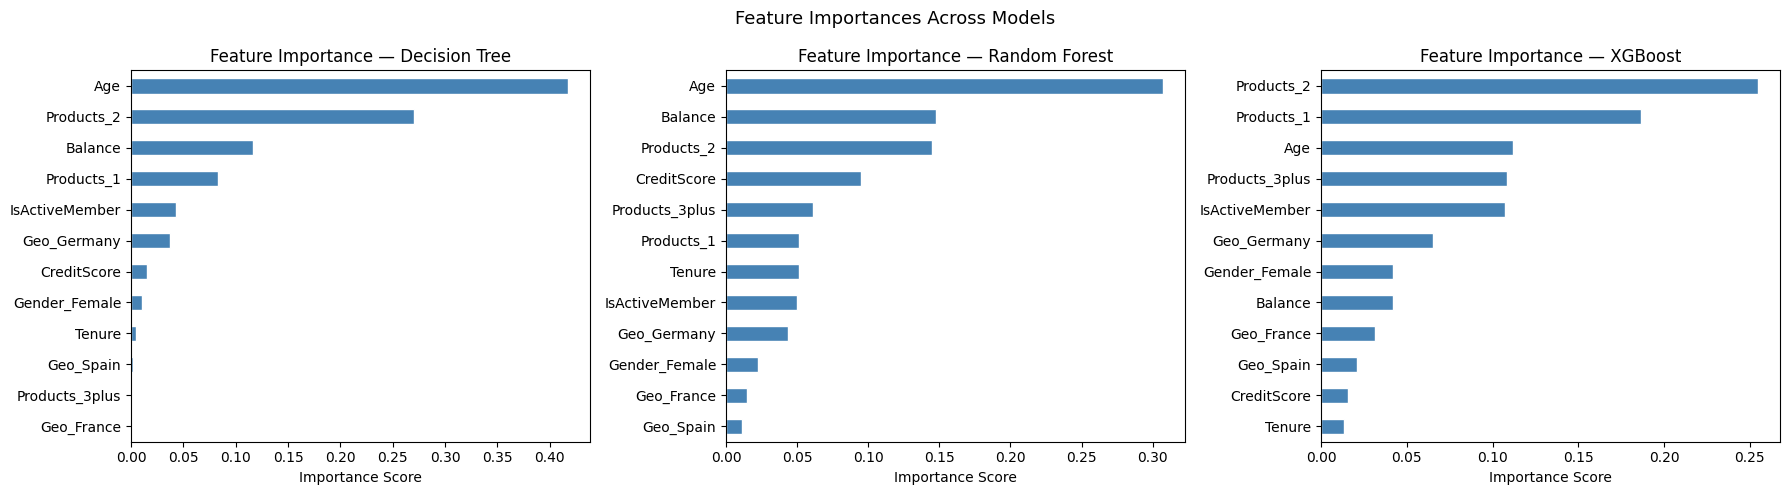

In [16]:
# --- Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importances Across Models', fontsize=13)
plt.tight_layout()
plt.show()

## Threshold Optimization

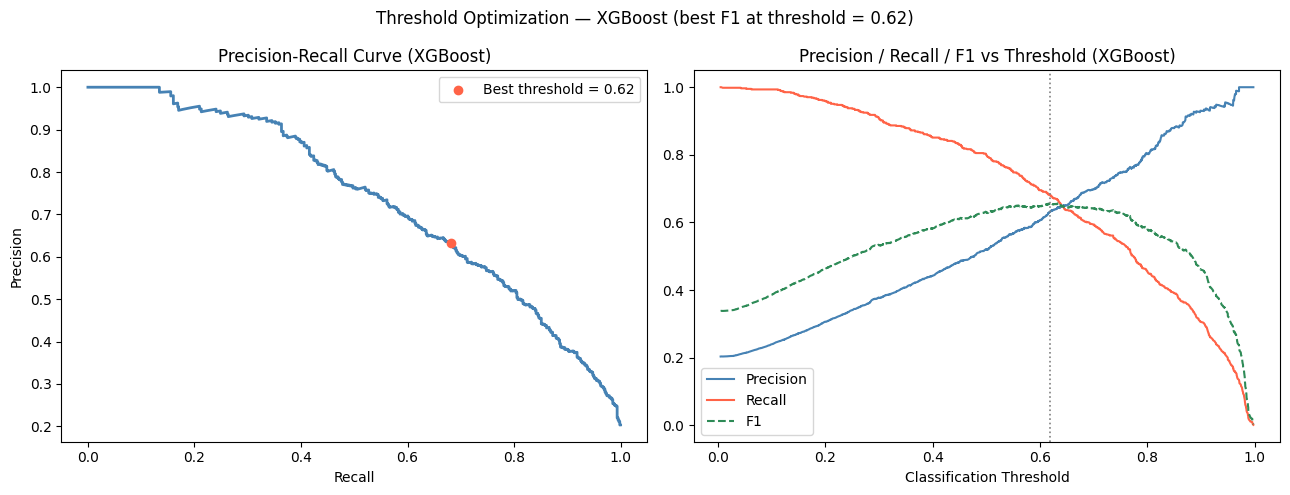

In [17]:
# --- Threshold Optimization (XGBoost — best AUC) ---
y_prob_xgb = xgb_grid.best_estimator_.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

f1_scores_thresh = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = f1_scores_thresh.argmax()
best_threshold = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='tomato', zorder=5,
                label=f'Best threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (XGBoost)')
axes[0].legend()

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='tomato')
axes[1].plot(thresholds, f1_scores_thresh, label='F1', color='seagreen', linestyle='--')
axes[1].axvline(x=best_threshold, color='gray', linestyle=':', linewidth=1.2)
axes[1].set_xlabel('Classification Threshold')
axes[1].set_title('Precision / Recall / F1 vs Threshold (XGBoost)')
axes[1].legend()

plt.suptitle(f'Threshold Optimization — XGBoost (best F1 at threshold = {best_threshold:.2f})', fontsize=12)
plt.tight_layout()
plt.show()

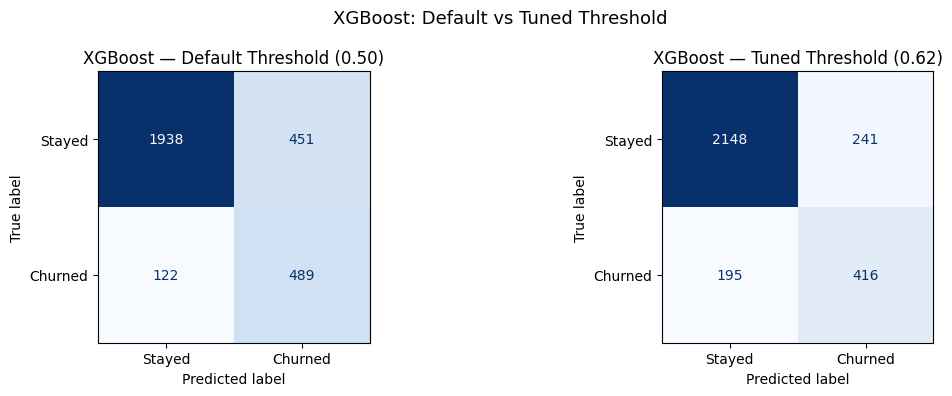

           Precision  Recall      F1
Threshold                           
0.50          0.5202  0.8003  0.6306
0.62          0.6332  0.6809  0.6562


In [18]:
# --- Confusion Matrix: Default vs Tuned Threshold (XGBoost) ---
y_pred_default = (y_prob_xgb >= 0.50).astype(int)
y_pred_tuned   = (y_prob_xgb >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_default),
                       display_labels=['Stayed', 'Churned']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Default Threshold (0.50)')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned),
                       display_labels=['Stayed', 'Churned']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'XGBoost — Tuned Threshold ({best_threshold:.2f})')

plt.suptitle('XGBoost: Default vs Tuned Threshold', fontsize=13)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame([
    {'Threshold': 0.50,
     'Precision': precision_score(y_test, y_pred_default),
     'Recall':    recall_score(y_test, y_pred_default),
     'F1':        f1_score(y_test, y_pred_default)},
    {'Threshold': round(float(best_threshold), 2),
     'Precision': precision_score(y_test, y_pred_tuned),
     'Recall':    recall_score(y_test, y_pred_tuned),
     'F1':        f1_score(y_test, y_pred_tuned)},
]).set_index('Threshold')
print(comparison.round(4).to_string())

## Business Impact: False Negatives vs False Positives

In [22]:
# ── Business Impact: False Negatives vs False Positives ──────────────────────
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tuned).ravel()

print(f"XGBoost — Default threshold (0.50):  FN = {fn_d},  FP = {fp_d}")
print(f"XGBoost — Tuned  threshold ({best_threshold:.2f}): FN = {fn_t},  FP = {fp_t}")

print(f"""
False Negative (FN): predicted Stay, actually Churned
  The bank misses the at-risk customer and has no chance to intervene.
  The customer leaves with no retention attempt,
  and re-acquiring customers is more expensive than retaining them.

False Positive (FP): predicted Churn, actually Stayed
  The bank targets a customer who was not going to leave anyway.

Final Conclusion: Use the threshold of 0.5 over the best threshold, 
  becuse it is more lax than the best one.
  A higher threshold means model is more confident an individual is likely to leave. 
  This would mean lower FPs, but also means fewer customers get flagged.
  Therefore setting the threshold to 0.5 is better, because flagging
  someone who is false positive has almost no cost associated to us, 
  over losing potential custoemrs who churn, while the model fails to flag them.
""")

XGBoost — Default threshold (0.50):  FN = 122,  FP = 451
XGBoost — Tuned  threshold (0.62): FN = 195,  FP = 241

False Negative (FN): predicted Stay, actually Churned
  The bank misses the at-risk customer and has no chance to intervene.
  The customer leaves with no retention attempt,
  and re-acquiring customers is more expensive than retaining them.

False Positive (FP): predicted Churn, actually Stayed
  The bank targets a customer who was not going to leave anyway.

Final Conclusion: Use the threshold of 0.5 over the best threshold, 
  becuse it is more lax than the best one.
  A higher threshold means model is more confident an individual is likely to leave. 
  This would mean lower FPs, but also means fewer customers get flagged.
  Therefore setting the threshold to 0.5 is better, because flagging
  someone who is false positive has almost no cost associated to us, 
  over losing potential custoemrs who churn, while the model fails to flag them.

